#Random Agent Experiment



**Random Agent Baseline:**
*   A `RandomAgent` was defined, which makes random actions within the `AutoScalingEnv`'s action space.
*   This agent was evaluated across 'train', 'validation', and 'test' datasets for a specified number of episodes and maximum steps.
*   Performance metrics such as mean return, mean utilization, SLA violation rate, and mean capacity were calculated and summarized for each data split (train, validation, and test).
*   Visualizations were generated for the Random Agent's performance on the test set, including:
    *   Plots showing the `current_capacity` and `demand_cpu` over time.
    *   Plots illustrating `utilization` against the `target_utilization` and `sla_threshold`.
    *   Plots of the `reward` obtained at each step.
    *   A bar plot displaying the distribution (counts) of each `action` taken by the random agent.
    *   A time-series plot showing the `action` taken at each step.

In essence, the Random Agent serves as a baseline to understand the inherent difficulty of the autoscaling problem and to compare against more sophisticated agents like the DQN.

#Random Agent

In [ ]:
class RandomAgent:
    def __init__(self, action_space):
        self.action_space = action_space

    def act(self, state, epsilon=None, eps=None):
        return self.action_space.sample()

    def step(self, *args, **kwargs):
        pass


In [ ]:
env_random = AutoScalingEnv(df_usage)

random_agent = RandomAgent(env_random.action_space)


In [ ]:
num_random_eval_eps = 10
max_random_steps = 1000

# --- Train window ---
random_train_scores, random_eval_train = evaluate_agent(
    random_agent,
    env_random,
    num_random_eval_eps,
    max_random_steps,
    split="train",
    use_random_windows=True
)

# --- Validation window ---
random_val_scores, random_eval_val = evaluate_agent(
    random_agent,
    env_random,
    num_random_eval_eps,
    max_random_steps,
    split="val",
    use_random_windows=True
)

# --- Test window ---
random_test_scores, random_eval_test = evaluate_agent(
    random_agent,
    env_random,
    num_random_eval_eps,
    max_random_steps,
    split="test",
    use_random_windows=True
)

print("Random baseline evaluation complete.")


Evaluation Episode 1	Score: -7429.85
Evaluation Episode 2	Score: -9774.08
Evaluation Episode 3	Score: -19508.38
Evaluation Episode 4	Score: -15504.51
Evaluation Episode 5	Score: -10598.27
Evaluation Episode 6	Score: -10752.15
Evaluation Episode 7	Score: -7393.96
Evaluation Episode 8	Score: -1477.09
Evaluation Episode 9	Score: -9027.63
Evaluation Episode 10	Score: -10392.32

Average Evaluation Score over 10 episodes: -10185.82
Evaluation Episode 1	Score: -19758.01
Evaluation Episode 2	Score: -2434.08
Evaluation Episode 3	Score: -10927.20
Evaluation Episode 4	Score: -5736.06
Evaluation Episode 5	Score: -19420.22
Evaluation Episode 6	Score: -6251.37
Evaluation Episode 7	Score: -12325.05
Evaluation Episode 8	Score: -6983.19
Evaluation Episode 9	Score: -22925.24
Evaluation Episode 10	Score: -16542.55

Average Evaluation Score over 10 episodes: -12330.30
Evaluation Episode 1	Score: -4669.47
Evaluation Episode 2	Score: -3634.97
Evaluation Episode 3	Score: -13076.39
Evaluation Episode 4	Score:

In [ ]:
def summarize_split(df, env, name):
    if "episode" in df.columns:
        ep_returns = df.groupby("episode")["reward"].sum()
        mean_return = ep_returns.mean()
    else:
        mean_return = df["reward"].sum()

    mean_util = df["utilization"].mean()
    sla_rate = (df["utilization"] > env.sla_threshold).mean()
    mean_capacity = df["current_capacity"].mean()

    return {
        "name": name,
        "mean_return": mean_return,
        "mean_utilization": mean_util,
        "sla_violation_rate": sla_rate,
        "mean_capacity": mean_capacity,
    }

rows = []
rows.append(summarize_split(random_eval_train, env_random, "Random_train"))
rows.append(summarize_split(random_eval_val, env_random, "Random_val"))
rows.append(summarize_split(random_eval_test, env_random, "Random_test"))

random_summary = pd.DataFrame(rows).set_index("name")
random_summary


,mean_return,mean_utilization,sla_violation_rate,mean_capacity
name,,,,
Random_train,-101858.237788,1.120877,0.4154,7.2326
Random_val,-123302.968685,1.259316,0.4423,6.7517
Random_test,-86849.454782,1.064478,0.4249,7.9784


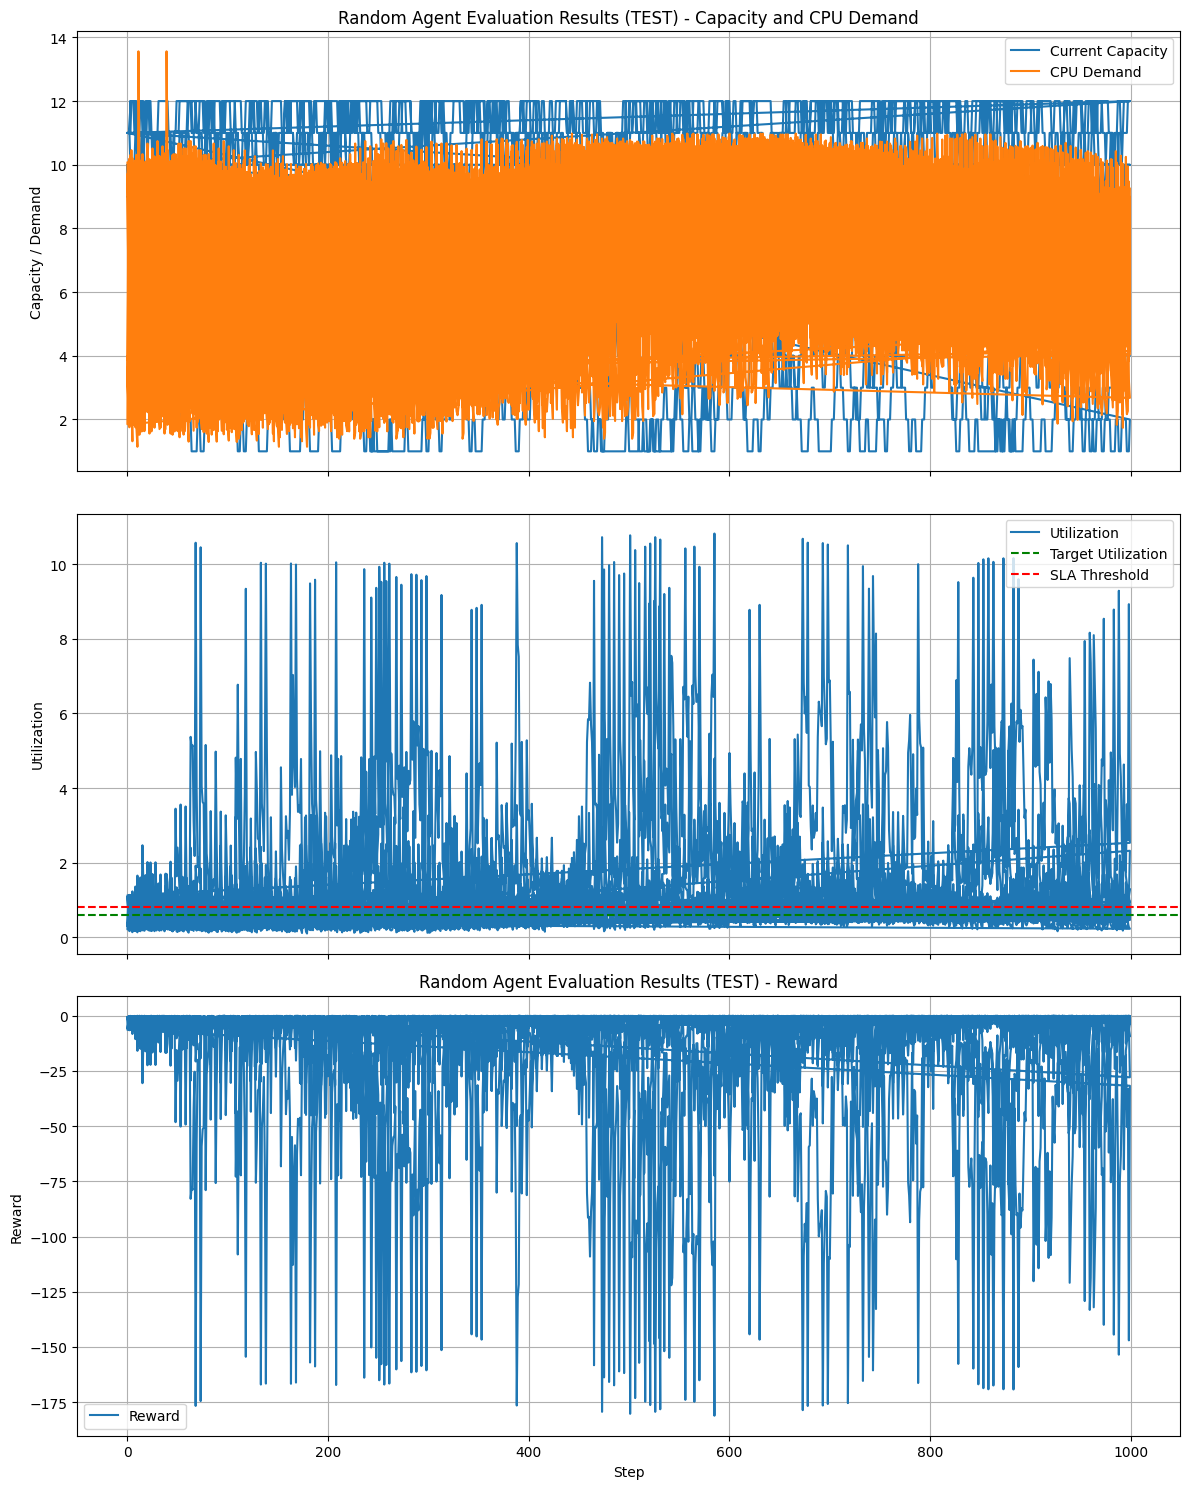

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_random = random_eval_test

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 15), sharex=True)

# Plot Current Capacity and CPU Demand
axes[0].plot(df_random.index, df_random['current_capacity'], label='Current Capacity')
axes[0].plot(df_random.index, df_random['demand_cpu'], label='CPU Demand')
axes[0].set_ylabel('Capacity / Demand')
axes[0].set_title('Random Agent Evaluation Results (TEST) - Capacity and CPU Demand')
axes[0].legend()
axes[0].grid(True)

# Plot Utilization and Target Utilization
axes[1].plot(df_random.index, df_random['utilization'], label='Utilization')
axes[1].axhline(y=env_random.target_utilization, color='g', linestyle='--', label='Target Utilization')
axes[1].axhline(y=env_random.sla_threshold, color='r', linestyle='--', label='SLA Threshold')
axes[1].set_ylabel('Utilization')
axes[1].legend()
axes[1].grid(True)

# Plot Reward
axes[2].plot(df_random.index, df_random['reward'], label='Reward')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Reward')
axes[2].set_title('Random Agent Evaluation Results (TEST) - Reward')
axes[2].legend()
axes[2].grid(True)

# Adjust layout and display plots
plt.tight_layout()
plt.show()

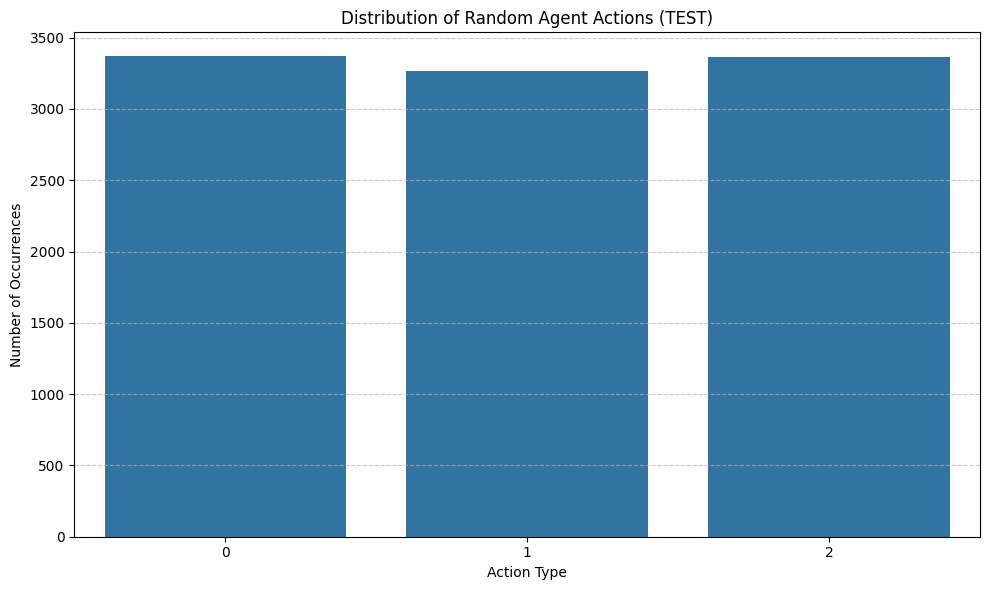

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each action
action_counts = df_random['action'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=action_counts.index, y=action_counts.values)
plt.xlabel('Action Type')
plt.ylabel('Number of Occurrences')
plt.title('Distribution of Random Agent Actions (TEST)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

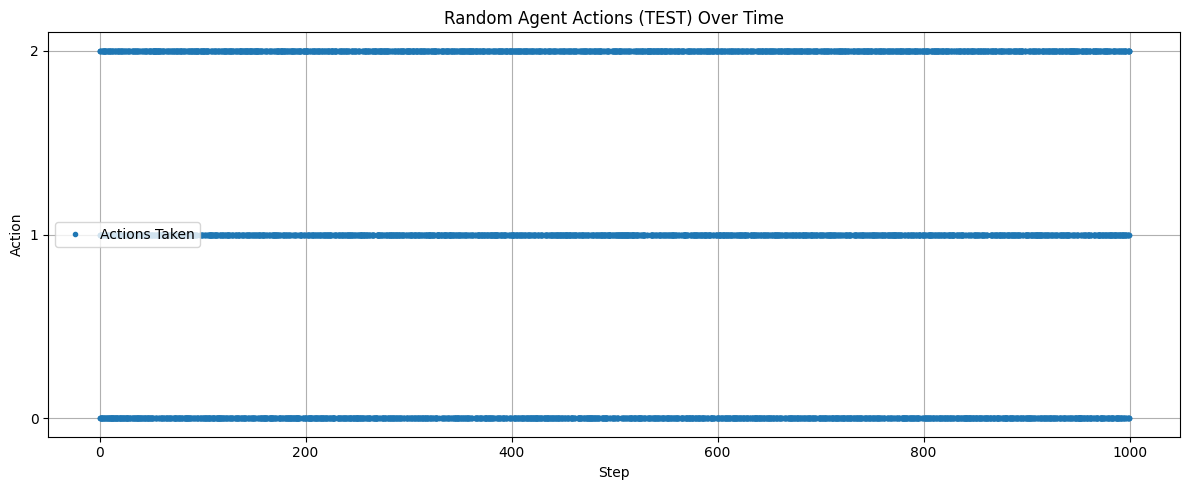

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 5))
plt.plot(df_random.index, df_random['action'], label='Actions Taken', marker='.', linestyle='None')
plt.xlabel('Step')
plt.ylabel('Action')
plt.title('Random Agent Actions (TEST) Over Time')
plt.yticks(df_random['action'].unique()) # Show only the actual action values on y-axis
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()